<a href="https://colab.research.google.com/github/MSagri05/Sagri_Manmeet_LabTask/blob/main/LabTask03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LAB TASK 03 BY MANMEET SAGRI**

**Importing libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt

**blue and hot pink aesthetic**

In [2]:
sns.set_theme(style="whitegrid")
sns.set_palette(["#FF69B4", "#1E90FF", "#FF1493", "#00BFFF", "#C71585"])

**Upload CSV file**

In [4]:
df = pd.read_csv("music_streams.csv")

**File Details**

In [5]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_id           1200 non-null   object 
 1   title              1200 non-null   object 
 2   artist             1200 non-null   object 
 3   genre              1200 non-null   object 
 4   year               1200 non-null   int64  
 5   duration           1200 non-null   object 
 6   duration_sec       1200 non-null   int64  
 7   tempo_bpm          1200 non-null   int64  
 8   key                1200 non-null   object 
 9   energy             1200 non-null   float64
 10  danceability       1200 non-null   float64
 11  valence            1200 non-null   float64
 12  acousticness       1200 non-null   float64
 13  speechiness        1200 non-null   float64
 14  loudness_db        1200 non-null   float64
 15  explicit           1200 non-null   bool   
 16  streams_millions   1200 

In [7]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


In [8]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

## Histogram

### Monthly Streams (reusing TA's notebook example)

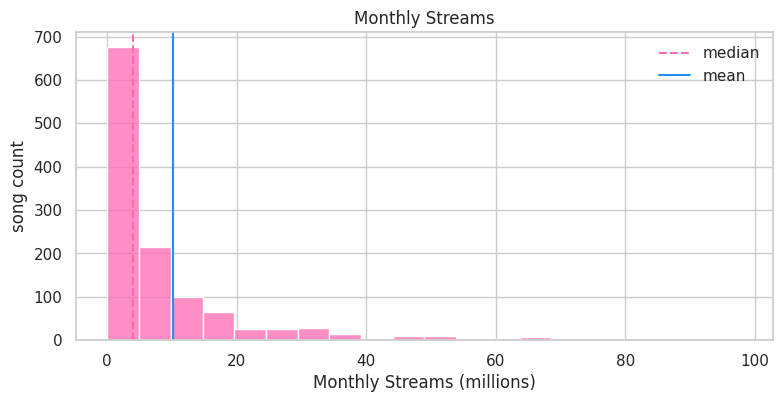

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df[df.streams_millions < 100], x="streams_millions", bins=20, ax=ax)
ax.axvline(median, color="#FF69B4", linestyle="--", label="median")
ax.axvline(mean, color="#1E90FF", label="mean")
ax.legend(frameon=False)
ax.set_xlabel("Monthly Streams (millions)")
ax.set_ylabel("song count")
ax.set_title("Monthly Streams")
plt.show()

most songs get under 20M streams, the distribution is really right skewed which makes sense because only a tiny number of tracks actually blow up

## BoxPlots

### Energy by Genre (reusing TA's notebook example)

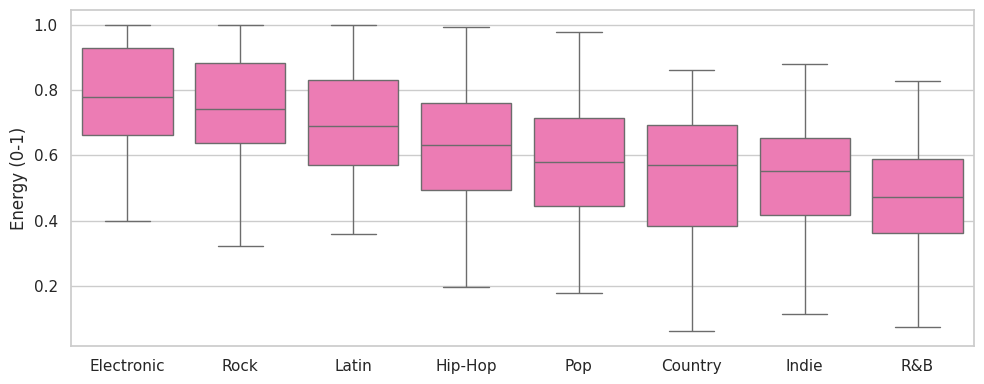

In [10]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="genre", y="energy", order=order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Energy (0-1)")
plt.tight_layout()
plt.show()

Electronic and Rock are the most energetic genres which is not surprising at all, R&B is at the bottom and that also makes complete sense

## Scatterplot

### Energy vs Danceability (reusing TA's notebook example)

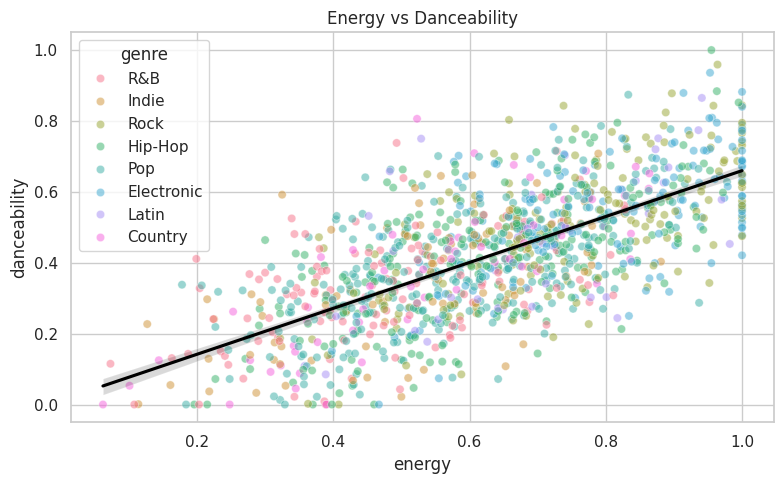

In [13]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="energy", y="danceability", hue="genre", alpha=0.5, ax=ax)
sns.regplot(data=df, x="energy", y="danceability", scatter=False, color="black")
ax.set_title("Energy vs Danceability")
plt.tight_layout()
plt.show()

clear positive correlation between energy and danceability, the more energetic a song is the more danceable it tends to be across all genres

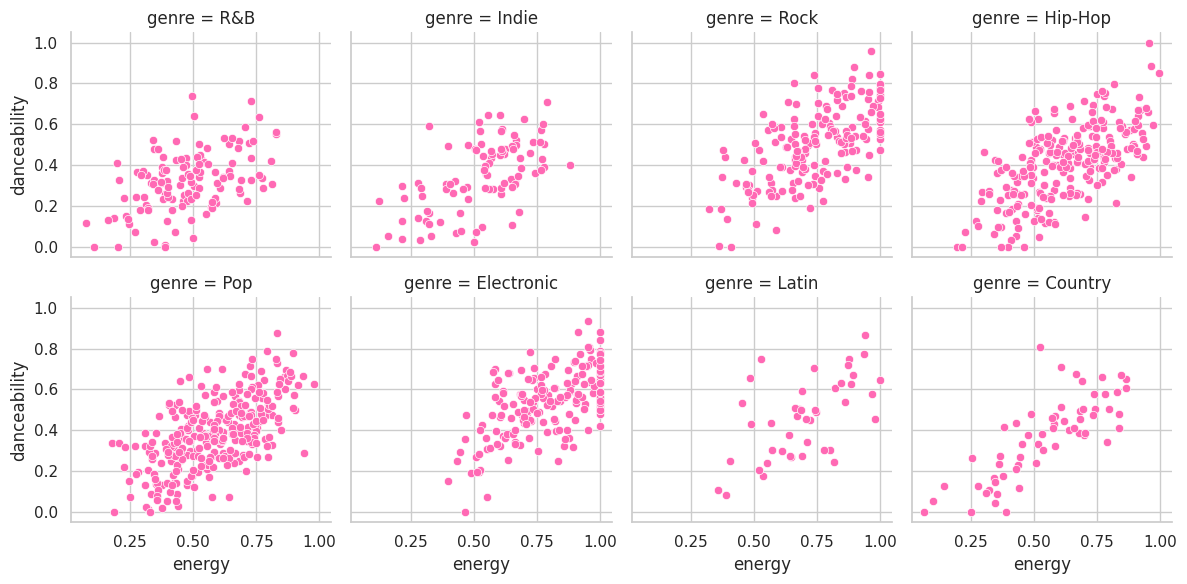

In [14]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")
plt.show()

breaking it down by genre you can see the pattern holds everywhere, Hip-Hop and Rock have the most spread

## Line Chart and Friends

### Streams by Genre Over Time (reusing TA's notebook example)

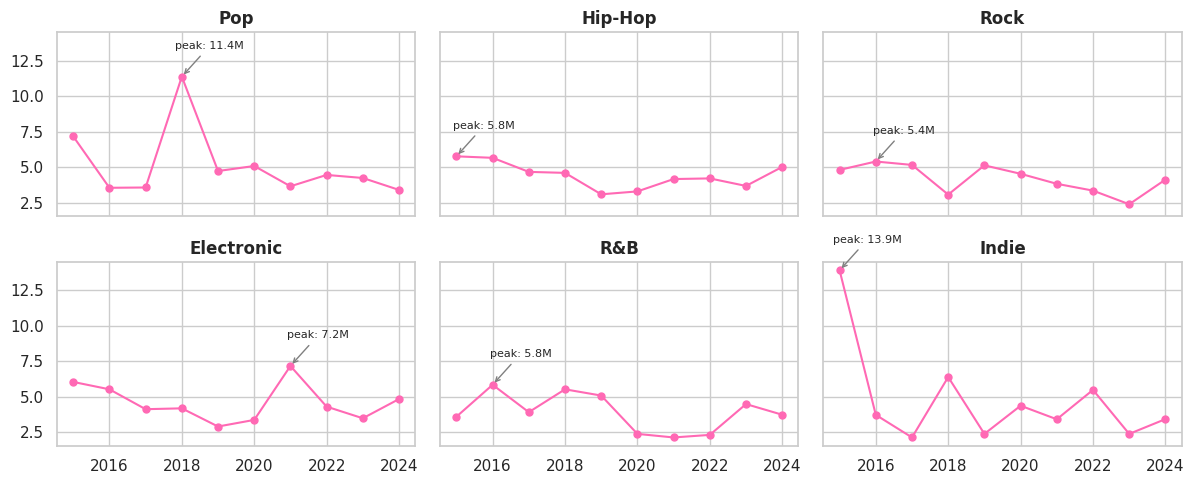

In [15]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]
trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(
        f"peak: {peak.streams_millions:.1f}M",
        xy=(peak.year, peak.streams_millions),
        xytext=(20, 20),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="gray", lw=1)
    )
    ax.set_title(genre, fontweight="bold")

plt.tight_layout()
plt.show()

Pop had a huge spike in 2018 and then kind of just dropped, Indie peaked super early at 13.9M in 2015

### My Line Chart: Danceability Trend by Genre Over Time

I wanted to track how danceable each genre has been year over year instead of just streams. I thought it would tell a more interesting story about how the sound of each genre is actually shifting over time.

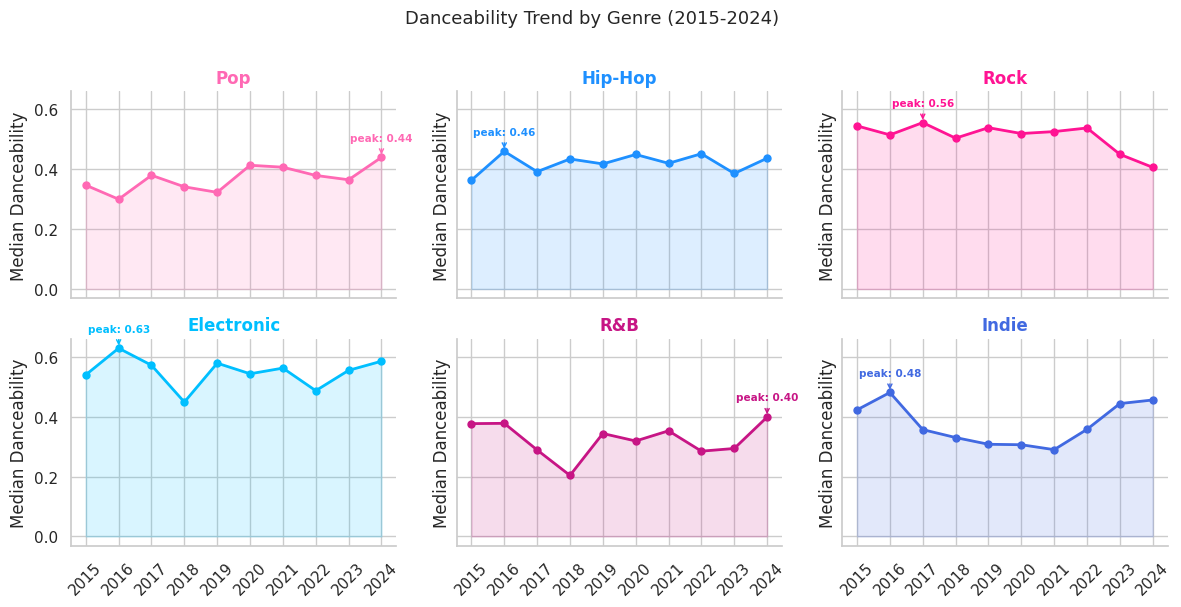

In [16]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]

dance_trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["danceability"].median().reset_index()

palette = {
    "Pop": "#FF69B4",
    "Hip-Hop": "#1E90FF",
    "Rock": "#FF1493",
    "Electronic": "#00BFFF",
    "R&B": "#C71585",
    "Indie": "#4169E1"
}

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = dance_trend[dance_trend.genre == genre]
    color = palette[genre]
    ax.fill_between(subD.year, subD.danceability, alpha=0.15, color=color)
    ax.plot(subD.year, subD.danceability, marker="o", ms=5, color=color, lw=2)
    peak = subD.loc[subD.danceability.idxmax()]
    ax.annotate(
        f"peak: {peak.danceability:.2f}",
        xy=(peak.year, peak.danceability),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=7.5,
        color=color,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=color, lw=1)
    )
    ax.set_title(genre, fontweight="bold", color=color)
    ax.set_ylabel("Median Danceability")
    ax.set_xticks(range(2015, 2025))
    ax.tick_params(axis="x", rotation=45)
    sns.despine(ax=ax)

fig.suptitle("Danceability Trend by Genre (2015-2024)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Hip-Hop stays consistently high in danceability the whole time which makes sense, Rock is pretty flat and low throughout. I used fill_between and color coded each genre individually so it's way easier to read than a plain line chart. The shading also makes it look cleaner.

## Vega-Altair

### My Altair Chart: Average Audio Features by Genre using xOffset

I used the xOffset encoding channel from the Altair docs to compare energy, danceability and valence side by side for each genre. I wanted to see which genres have the most balanced audio profile and which ones are really one-dimensional.

In [24]:
import altair as alt ## re import alt air to debug script error
alt.data_transformers.enable("default")

features = ["energy", "danceability", "valence"]
genre_features = df.groupby("genre")[features].mean().reset_index()

melted = genre_features.melt(
    id_vars="genre",
    value_vars=features,
    var_name="feature",
    value_name="avg_value"
)

chart = alt.Chart(melted).mark_bar().encode(
    x=alt.X("genre:N", title="Genre"),
    y=alt.Y("avg_value:Q", title="Average Value", scale=alt.Scale(domain=[0, 1])),
    xOffset="feature:N",
    color=alt.Color("feature:N",
        scale=alt.Scale(
            domain=["energy", "danceability", "valence"],
            range=["#FF69B4", "#1E90FF", "#FF1493"]
        ),
        title="Feature"
    ),
    tooltip=["genre:N", "feature:N", alt.Tooltip("avg_value:Q", format=".2f")]
).properties(
    title="Average Energy, Danceability & Valence by Genre",
    width=550,
    height=300
)

chart

alt.Chart(...)

*i ran into script error Error loading script: https://cdn.jsdelivr.net/npm/vega-embed@6?noext, so i used ChatGPT to debug it and figured out i had to re-import altair and enable the default data transformer to fix the rendering issue*

this is my required Altair chart using xOffset like the linked example. Electronic has really high energy but low valence which means it's intense but not necessarily happy sounding. R&B is kind of the opposite, lower energy but higher valence. I picked these three features because together they basically describe the whole personality of a genre.